In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mucvK2QUbJpoJGP1RzY1")
project = rf.workspace("accident-detection-model").project("accident-detection-model")
version = project.version(2)
dataset = version.download("yolov8") 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.17.1 which is incompatible.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Accident-detection-model-2 in yolov8:: 100%|██████████| 6512/6512 [00:00<00:00, 7810.44it/s]


In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 24.6 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


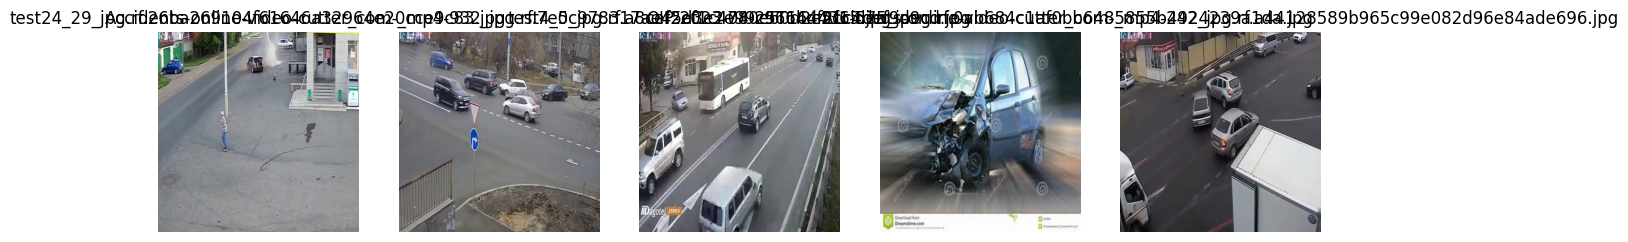

In [3]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Set the path to the images directory
image_dir = "/kaggle/working/Accident-detection-model-2/train/images"  # Update with your directory path

# Get a list of all image files
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Ensure there are enough images for random sampling, otherwise sample all
sample_size = min(5, len(image_files))  # Sample up to 5 images, or fewer if there aren't enough

# Display the random images
random_images = random.sample(image_files, sample_size)

# Display images
image_paths = [os.path.join(image_dir, img) for img in random_images]
images = [Image.open(img_path) for img_path in image_paths]

# Show the images
fig, axes = plt.subplots(1, sample_size, figsize=(15, 5))
for ax, img, img_path in zip(axes, images, image_paths):
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path))
    ax.axis('off')

plt.show()


In [4]:
from ultralytics import YOLO

# Initialize the YOLO model
model = YOLO("yolov8n.pt")  # 'yolov8n.pt' is the smallest YOLOv8 model; consider 'yolov8s.pt' for larger capacity.

# Train the model with specified parameters
results = model.train(
    data="/kaggle/working/Accident-detection-model-2/data.yaml",  # Adjust path to your data.yaml file
    epochs=500,                      # Number of epochs
    imgsz=640,                      # Image size (e.g., 640x640)
    batch=16,                       # Batch size; adjust according to available GPU memory
    project="output",  # Directory name to store results
    name="accident-detection-model",    # Experiment name
    cache=True                      # Cache images in memory for faster training
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 138MB/s]


Ultralytics 8.3.75 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/Accident-detection-model-2/data.yaml, epochs=500, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=output, name=accident-detection-model, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, sa

100%|██████████| 755k/755k [00:00<00:00, 25.2MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...


310 epochs completed in 2.646 hours.
Optimizer stripped from output/accident-detection-model/weights/last.pt, 6.3MB
Optimizer stripped from output/accident-detection-model/weights/best.pt, 6.3MB

Validating output/accident-detection-model/weights/best.pt...
Ultralytics 8.3.75 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:02<00:00,  4.52it/s]


                   all        371        288      0.829      0.694      0.701      0.312


invalid value encountered in less
invalid value encountered in less


Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to output/accident-detection-model


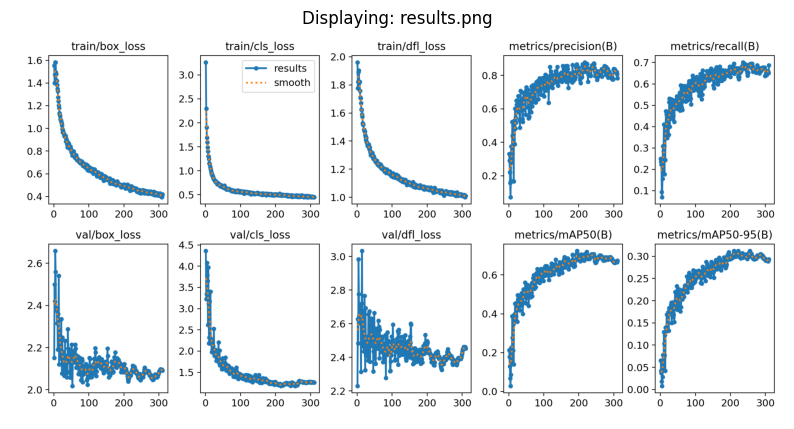

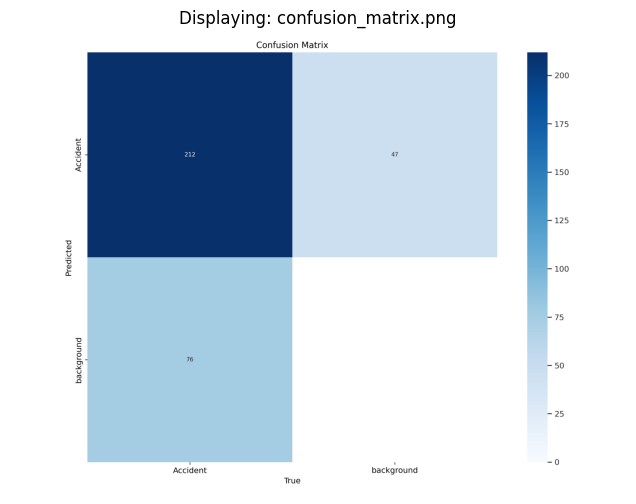

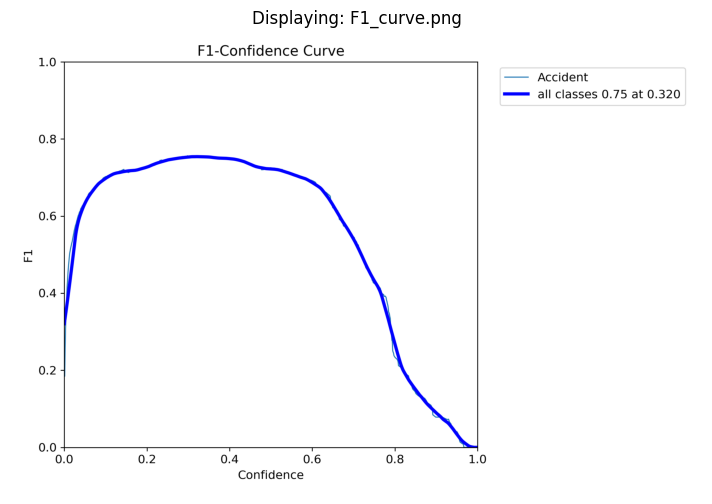

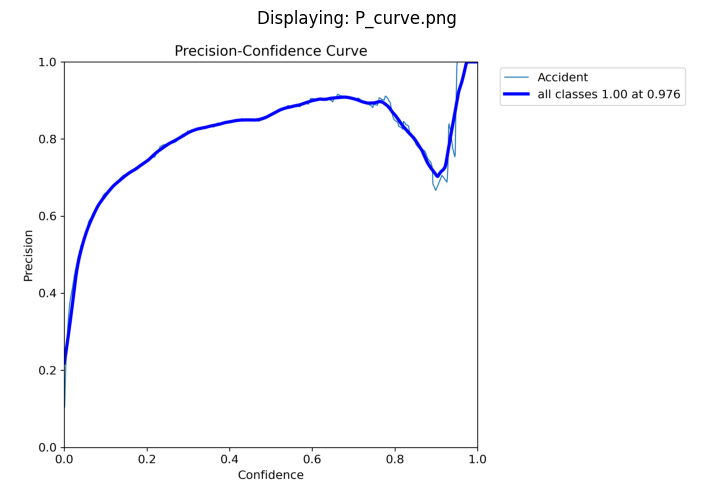

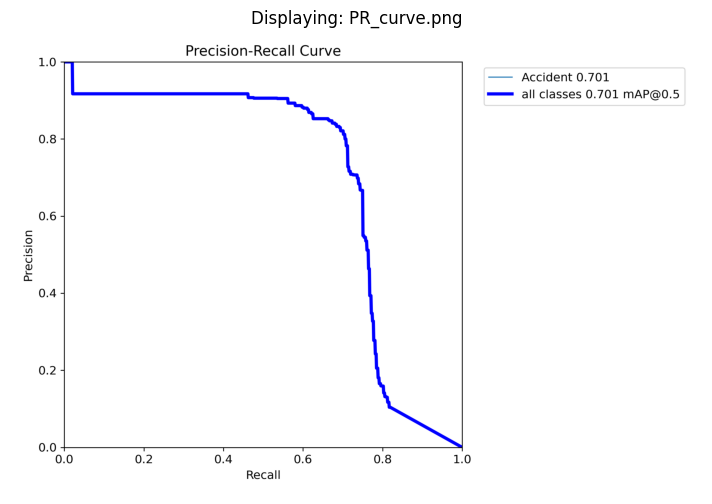

In [8]:
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimg

# Define the directory where the plots are saved
results_dir = "/kaggle/working/output/accident-detection-model"

# List of plot files to display
plot_files = [
    "results.png",                # Overall training results plot
    "confusion_matrix.png",       # Confusion matrix plot
    "F1_curve.png", # Precision-recall curve plot
    "P_curve.png",              # Loss plot
    "PR_curve.png",             # Train loss plot
]

# Iterate over each plot file and display it using matplotlib
for plot_file in plot_files:
    plot_path = os.path.join(results_dir, plot_file)
    
    # Check if the plot file exists
    if os.path.exists(plot_path):
        # Load the plot image
        img = mpimg.imread(plot_path)
        
        # Display the image
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')  # Hide axis
        plt.title(f"Displaying: {plot_file}")
        plt.show()
    else:
        print(f"{plot_file} not found in {results_dir}")
